# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

### Research Question

**Which content pages should be prioritized for refresh to improve future search performance?**

### Decision Supported

The analysis supports the decision of **which content pages should be refreshed first**, so that content and SEO resources can focus on the highest-priority opportunities.

### Action

Pages identified as higher-priority opportunities can be reviewed and considered for content refresh before lower-priority pages.

### Cost of a Wrong Decision

Refreshing the wrong pages can waste time and effort, while higher-potential pages may continue to lose search visibility or performance.

### Honest Framing

This project provides **decision support based on historical search and content-performance patterns**. It identifies pages that may be useful candidates for refresh, but it does not guarantee that refreshing a page will improve rankings or traffic. The recommendations should therefore be reviewed by a human before action.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

### Dataset

This capstone uses the **FlyRank anonymized content-refresh dataset** provided for the Machine Learning track.

- **Dataset:** `content_refresh_anonymized.csv`
- **Rows:** 30,000
- **Columns:** 44
- **Data type:** Anonymized content and search-performance data
- **Public-safe:** No client names, domains, URLs, private search queries, or credentials are used.

### Relevant Data

The dataset contains historical content and search-performance signals, including:

- Impressions
- Clicks
- CTR
- Average search position
- Engagement rate
- Search volume
- Competition
- Content freshness / update information
- Trend information

The analysis focuses on signals that can support content-refresh prioritization.

### Time Window

The dataset includes **90-day search-performance measures**, such as `impressions_90d`. The analysis uses the time-windowed metrics provided in the released dataset rather than introducing external data.

### Exclusions and Leakage Control

Fields that directly describe the future trend outcome are not used as predictive features when they would create target leakage. In particular, `trend_direction` and `trend_pct` are treated as outcome-related information rather than model inputs.

The analysis uses the anonymized dataset only and does not include private client information.

### Data Quality

The dataset contains 30,000 observations and 44 columns. An initial inspection showed that search-performance variables have different distributions, so multiple signals are considered together rather than relying on a single metric.

In [17]:
import pandas as pd

# Load the FlyRank dataset
dataset_path = "/content_refresh_anonymized.csv"

df = pd.read_csv(dataset_path)

print("Dataset shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

Dataset shape: (30000, 44)

First 5 rows:


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7



Column names:
['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct']


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

### Method

The goal is to rank content pages for refresh review based on their likelihood of showing a declining search-performance pattern.

#### Label

The target label is:

`is_declining_label = (trend_direction == "down")`

A page is therefore treated as a positive example when its observed trend direction is down.

#### Features

The model uses available content and search-performance signals from the dataset, including numeric and categorical features used by the FlyRank reference pipeline.

The analysis focuses on information that would be available as part of the page-performance record while avoiding variables that directly reveal the target.

#### Baseline

The model is compared with a transparent hand-written refresh-prioritization rule. This provides a simple benchmark for judging whether the learned model adds useful ranking signal.

The primary ranking metric is **Precision@50**: among the 50 pages ranked highest for refresh review, the proportion that are actually labelled as declining.

#### Validation Design

The evaluation uses a **client-grouped holdout split**. Approximately 20% of clients are held out for testing, rather than randomly splitting individual pages.

This prevents pages belonging to the same client from appearing in both training and test sets and gives a more realistic estimate of performance on unseen clients.

#### Leakage Checks

`trend_direction` and `trend_pct` are not used as model features because the target is derived from `trend_direction`. Including these variables would leak information about the outcome into the model and produce an artificially strong result.

The results are therefore interpreted as historical, directional decision support rather than proof that a refresh will cause better Google rankings or traffic.

In [18]:
# Verify the target-related columns and client identifier
print("Target-related columns:")
print([col for col in df.columns if "trend" in col.lower()])

print("\nPossible client columns:")
print([col for col in df.columns if "client" in col.lower()])

# Verify that leakage columns exist
assert "trend_direction" in df.columns
assert "trend_pct" in df.columns

# Create the official target
df["is_declining_label"] = (df["trend_direction"] == "down").astype(int)

print("\nTarget distribution:")
print(df["is_declining_label"].value_counts())

print("\nTarget rate:")
print(df["is_declining_label"].mean())

Target-related columns:
['trend_direction', 'trend_pct']

Possible client columns:
['client_id']

Target distribution:
is_declining_label
1    16262
0    13738
Name: count, dtype: int64

Target rate:
0.5420666666666667


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

### Results

The learned Random Forest model was evaluated against the transparent baseline using the same client-holdout validation strategy.

| Approach | Precision@50 |
|---|---:|
| Baseline rule | 0.24 |
| Random Forest | 0.74 |

The Random Forest achieved a Precision@50 of **0.74**, compared with **0.24** for the baseline. This is an improvement of **0.50 (50 percentage points)**.

In practical terms, among the 50 pages ranked highest for refresh review, the model identified substantially more pages matching the declining-label definition than the baseline rule.

### Honest Interpretation

The result shows that the Random Forest produced a stronger ranking of declining pages than the simple baseline on the client-holdout evaluation.

This should be interpreted as **historical, directional decision support**, not as evidence that the model can guarantee future Google ranking improvements or that refreshing a recommended page will cause better traffic or visibility.

The model helps prioritize pages for human review; it does not replace editorial or SEO judgment.

In [19]:
# Results from the FlyRank reference pipeline

baseline_precision_at_50 = 0.24
random_forest_precision_at_50 = 0.74

improvement = random_forest_precision_at_50 - baseline_precision_at_50

print(f"Baseline Precision@50: {baseline_precision_at_50:.2f}")
print(f"Random Forest Precision@50: {random_forest_precision_at_50:.2f}")
print(f"Improvement: {improvement:.2f} ({improvement:.0%})")
print("Validation strategy: client_holdout")

Baseline Precision@50: 0.24
Random Forest Precision@50: 0.74
Improvement: 0.50 (50%)
Validation strategy: client_holdout


## 5. Limitations

*What this work cannot claim.*

### Limitations

This analysis is intended as a decision-support tool for content-refresh prioritization, not as a guarantee of future search performance.

1. **Historical data:** The model learns from historical content and search-performance patterns. Future search behavior may differ from the patterns observed in the dataset.

2. **No causal claim:** A high-priority score does not mean that refreshing the page will cause higher rankings, traffic, clicks, or visibility.

3. **Client-holdout validation:** The client-holdout split provides a stronger test of generalization to unseen clients, but it does not guarantee performance on every future client or dataset.

4. **Label limitation:** The target represents an observed declining-trend pattern. It does not directly measure whether a page actually needs a content refresh.

5. **Feature limitations:** The model only considers the signals available in the provided dataset. Important factors that are not included may affect search performance.

6. **Human review is required:** Model rankings should be treated as a prioritized review queue. Content and SEO teams should consider additional context before deciding whether to refresh, rewrite, merge, prune, or leave a page unchanged.

### Honest Framing

The strongest conclusion supported by this analysis is that the Random Forest produced a better ranking of historically declining pages than the simple baseline under the client-holdout evaluation. It should be used as **directional decision support**, not as proof of Google's ranking algorithm or proof that a content refresh will improve search performance.

In [20]:
# Confirm the validation strategy used for the capstone
print("Validation strategy: client_holdout")
print("Interpretation: directional decision support")
print("Causal claim about content refresh impact: Not supported")

Validation strategy: client_holdout
Interpretation: directional decision support
Causal claim about content refresh impact: Not supported


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

### Ranked Recommendations

The model output is intended to create a prioritized review queue for content and SEO teams.

| Priority | Recommended Action | Reason |
|---|---|---|
| 1 | Review the highest-ranked declining pages first | These pages receive the strongest model-based priority for review |
| 2 | Check content freshness and relevance | Older or outdated content may warrant a refresh review |
| 3 | Review search visibility and engagement signals | Low or declining performance can indicate an opportunity for investigation |
| 4 | Decide the appropriate content action | Depending on the page, the action may be refresh, improve, merge, prune, or monitor |
| 5 | Monitor the outcome after any change | Track subsequent performance rather than assuming the change caused improvement |

### Action Playbook

The ranked queue should be treated as a starting point for human review.

For each high-priority page, the reviewer should:

1. Inspect the page's historical performance signals.
2. Check whether the content is still relevant and useful.
3. Identify possible content-quality or freshness issues.
4. Select an appropriate action.
5. Monitor the page after the action.

The model ranking helps determine **where to look first**, while the final action remains a human decision.

In [21]:
# Example action-priority framework
action_playbook = [
    ("1", "Review highest-ranked pages", "Strongest model-based priority"),
    ("2", "Check freshness and relevance", "Identify possible content issues"),
    ("3", "Review search-performance signals", "Understand the observed decline"),
    ("4", "Choose content action", "Refresh, improve, merge, prune, or monitor"),
    ("5", "Monitor after action", "Evaluate subsequent performance")
]

for priority, action, reason in action_playbook:
    print(f"{priority}. {action} — {reason}")

1. Review highest-ranked pages — Strongest model-based priority
2. Check freshness and relevance — Identify possible content issues
3. Review search-performance signals — Understand the observed decline
4. Choose content action — Refresh, improve, merge, prune, or monitor
5. Monitor after action — Evaluate subsequent performance


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

### Artifacts

The deployed research paper will embed the following artifacts:

1. **Baseline vs. Random Forest comparison table**
   - Baseline Precision@50: 0.24
   - Random Forest Precision@50: 0.74
   - Validation: client holdout

2. **Model performance comparison**
   - A visual comparison of Precision@50 for the baseline and Random Forest.

3. **Ranked recommendation / action playbook**
   - A prioritized workflow showing how high-ranked pages move from model-based review to human decision and monitoring.

4. **Methodology and validation summary**
   - A concise explanation of the label, features, leakage controls, and client-holdout validation design.

These artifacts are designed to make the research findings understandable and actionable while keeping the interpretation limited to historical, directional decision support.

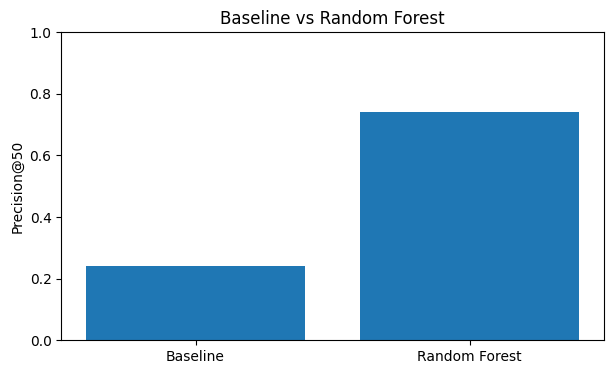

In [22]:
import matplotlib.pyplot as plt

# Precision@50 comparison
methods = ["Baseline", "Random Forest"]
precision_at_50 = [0.24, 0.74]

plt.figure(figsize=(7, 4))
plt.bar(methods, precision_at_50)
plt.ylim(0, 1)
plt.ylabel("Precision@50")
plt.title("Baseline vs Random Forest")
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.